# 下一课：CartPole + Prioritized Experience Replay

前面我们已经学过：
- 标准 DQN
- Double DQN
- Dueling DQN

这一课我们继续补一个很经典的改进：`Prioritized Experience Replay`，简称 `PER`。

它的核心问题是：

**经验池里的每条经验，真的都一样值得学吗？**

这一课你会学到：
- 为什么均匀随机采样有时不够高效
- 什么样的经验更值得优先学习
- PER 在代码里到底改了哪一块


## 1. 为什么要优先采样

普通 Replay Buffer 的做法是：
- 经验存进去以后
- 每次训练都从里面等概率随机抽样

这样做很简单，也能打乱样本相关性。

但问题是：
- 有些样本模型早就学会了，再看很多次意义不大
- 有些样本模型还学得很差，反而更值得多练几次

PER 的想法就是：

**让 TD error 更大的样本被抽到的概率更高。**

因为 TD error 大，通常说明这条样本“模型还没学明白”。


## 2. 这节课的教学简化版

完整的 PER 会涉及：
- 优先级分布
- 重要性采样权重 `importance sampling weights`
- 偏差修正

为了让主线清楚，这节课我们先做一个教学友好的版本：
- 用 TD error 的绝对值作为优先级
- 按优先级进行概率采样
- 暂时不把公式堆得太重

这样你能先抓住最重要的思想：

**经验池不再“人人平等”，而是优先训练更难的样本。**


In [1]:
import random
import warnings

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [2]:
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


In [3]:
env = gym.make('CartPole-v1')
state, info = env.reset(seed=42)
print('初始状态:', state)
print('状态维度:', env.observation_space.shape[0])
print('动作数量:', env.action_space.n)


初始状态: [ 0.027 -0.006  0.036  0.02 ]
状态维度: 4
动作数量: 2


In [4]:
def to_tensor(x, device):
    return torch.tensor(x, dtype=torch.float32, device=device)


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)


## 3. Prioritized Replay Buffer

这节课最关键的改动就在这里。

我们除了保存经验本身，还要保存每条经验的优先级 `priority`。

采样时：
- 优先级越大
- 被抽中的概率越高

训练完一个 batch 后，我们还会根据新的 TD error 回头更新这些样本的 priority。


In [5]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity=50000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = []
        self.pos = 0

    def push(self, state, action, reward, next_state, done):
        # 新样本先给一个当前最大优先级，确保它至少会被看到一次
        max_priority = max(self.priorities, default=1.0)
        transition = (state, action, reward, next_state, done)

        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
            self.priorities.append(max_priority)
        else:
            self.buffer[self.pos] = transition
            self.priorities[self.pos] = max_priority
            self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        priorities = np.array(self.priorities, dtype=np.float32)

        # alpha 控制“偏爱高优先级样本”的程度
        scaled_priorities = priorities ** self.alpha
        probs = scaled_priorities / scaled_priorities.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs, replace=False)
        batch = [self.buffer[idx] for idx in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), actions, rewards, np.array(next_states), dones, indices, probs[indices]

    def update_priorities(self, indices, td_errors, eps=1e-5):
        # TD error 越大，说明这条样本越“值得继续学”
        for idx, td_error in zip(indices, td_errors):
            self.priorities[idx] = float(abs(td_error) + eps)

    def __len__(self):
        return len(self.buffer)


## 4. 训练 DQN + Prioritized Replay

为了让焦点落在 PER 上，这节课我们先保留标准 DQN 风格的 target 计算。

你要重点看的是：
- 从 buffer 采样时不再均匀随机
- 每次训练后会用 TD error 更新 priority

这两步就是 PER 的主线。


In [6]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net = QNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=5e-4)
criterion = nn.SmoothL1Loss(reduction='none')
replay_buffer = PrioritizedReplayBuffer(capacity=50000, alpha=0.6)

gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.997
epsilon_min = 0.02
episodes = 300
max_steps = 500
batch_size = 128
target_update_freq = 20
train_start = 1000

episode_rewards = []
loss_history = []
buffer_sizes = []
priority_means = []

for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = to_tensor(state, device).unsqueeze(0)

        with torch.no_grad():
            q_values = q_net(state_tensor)

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(torch.argmax(q_values, dim=1).item())

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        buffer_sizes.append(len(replay_buffer))
        priority_means.append(float(np.mean(replay_buffer.priorities)))

        state = next_state
        total_reward += reward

        if len(replay_buffer) >= train_start:
            states, actions, rewards, next_states, dones, indices, sample_probs = replay_buffer.sample(batch_size)

            states_tensor = to_tensor(states, device)
            next_states_tensor = to_tensor(next_states, device)
            actions_tensor = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
            rewards_tensor = torch.tensor(rewards, dtype=torch.float32, device=device)
            dones_tensor = torch.tensor(dones, dtype=torch.float32, device=device)

            current_q_values = q_net(states_tensor)
            chosen_q_values = current_q_values.gather(1, actions_tensor).squeeze(1)

            with torch.no_grad():
                next_q_values = target_net(next_states_tensor)
                max_next_q_values = next_q_values.max(dim=1).values
                targets = rewards_tensor + gamma * max_next_q_values * (1 - dones_tensor)

            # 逐样本 loss，方便后面拿到每个样本自己的 TD error
            per_sample_loss = criterion(chosen_q_values, targets)
            loss = per_sample_loss.mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10.0)
            optimizer.step()

            loss_history.append(float(loss.item()))

            with torch.no_grad():
                td_errors = (targets - chosen_q_values).detach().abs().cpu().numpy()
            replay_buffer.update_priorities(indices, td_errors)

        if done:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 2))


训练完成。
最后 20 轮平均 reward: 48.0


## 5. 看训练曲线

这节课除了 reward，还多了一个值得观察的量：
- `priority_means`

它能帮助你直观看到经验池里优先级整体是怎么变化的。


C:\Users\80740\AppData\Local\Temp\ipykernel_12128\1031908068.py:28: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_12128\1031908068.py:28: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_12128\1031908068.py:28: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_12128\1031908068.py:28: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_12128\1031908068.py:28: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_12128\1031908068.py:28: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931})

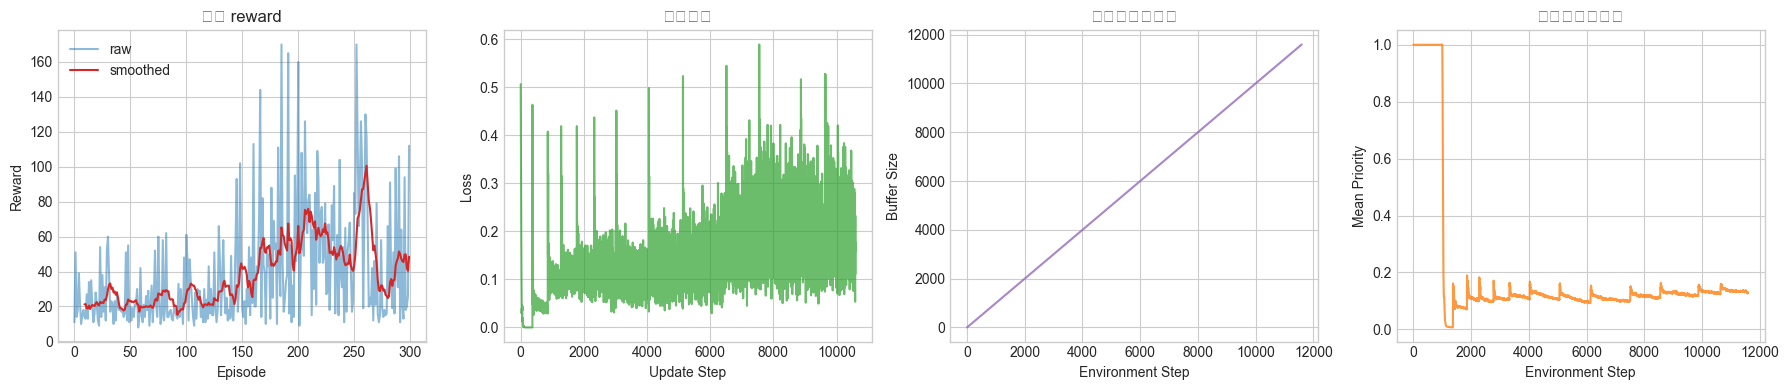

In [7]:
window = 10
smoothed_rewards = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(episode_rewards, color='#1f77b4', alpha=0.5, label='raw')
axes[0].plot(range(window - 1, len(episode_rewards)), smoothed_rewards, color='#d62728', label='smoothed')
axes[0].set_title('每轮 reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend()

axes[1].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[1].set_title('训练损失')
axes[1].set_xlabel('Update Step')
axes[1].set_ylabel('Loss')

axes[2].plot(buffer_sizes, color='#9467bd', alpha=0.8)
axes[2].set_title('经验池大小变化')
axes[2].set_xlabel('Environment Step')
axes[2].set_ylabel('Buffer Size')

axes[3].plot(priority_means, color='#ff7f0e', alpha=0.8)
axes[3].set_title('平均优先级变化')
axes[3].set_xlabel('Environment Step')
axes[3].set_ylabel('Mean Priority')

plt.tight_layout()
plt.show()


## 6. 多次测试平均表现

和前几课一样，我们测 5 次并看平均值，避免只被单次结果影响判断。


In [8]:
test_env = gym.make('CartPole-v1')
test_rewards = []

q_net.eval()
with torch.no_grad():
    for episode_idx in range(5):
        state, info = test_env.reset(seed=123 + episode_idx)
        test_reward = 0.0
        for step in range(500):
            state_tensor = to_tensor(state, device).unsqueeze(0)
            action = int(torch.argmax(q_net(state_tensor), dim=1).item())
            state, reward, terminated, truncated, info = test_env.step(action)
            test_reward += reward
            if terminated or truncated:
                break
        test_rewards.append(test_reward)

print('测试 rewards:', test_rewards)
print('测试平均 reward:', round(float(np.mean(test_rewards)), 2))
test_env.close()


测试 rewards: [106.0, 120.0, 109.0, 88.0, 90.0]
测试平均 reward: 102.6


## 7. 这节课最该记住什么

如果你想抓住 PER 的主线，就记住这句话：

**不是所有经验都一样重要，模型应该优先复习那些自己还没学好的样本。**

而“还没学好”的一个常见信号，就是 TD error 还比较大。


## 8. 下一课最自然学什么

学完这一课后，最自然的下一步就是把这些改进组合起来：
- Double DQN
- Dueling DQN
- Prioritized Replay

也就是很多教材里会提到的更完整 DQN 变体。

如果按学习顺序，我最推荐下一课做一个 `Rainbow-lite` 风格的组合版。 
